In [163]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from matplotlib.colors import LinearSegmentedColormap

# 颜色
c = 'coral'
c1 = 'yellowgreen'
base_c = 'aqua'

# 坐标轴刻度大小（和Beta_Collocation_points_plots.ipynb一致）
ticks_fontsize = 10

# XY轴标签字体大小（和Beta_Collocation_points_plots.ipynb一致）
label_fontsize = 14

# 动态colorbar格式化函数
def format_colorbar_tick(x, p):
    """
    动态设置colorbar刻度的小数点位数
    绝对值<1: 3位; 1<=绝对值<10: 2位; 10<=绝对值<100: 1位; 绝对值>=100: 0位
    """
    abs_x = abs(x)
    if abs_x < 1:
        return f'{x:.3f}'
    elif abs_x < 10:
        return f'{x:.2f}'
    elif abs_x < 100:
        return f'{x:.1f}'
    else:
        return f'{x:.0f}'

def truncated_cmap(cmap_name, minval=0.0, maxval=1.0, n=256):
    """Return a copy of cmap_name trimmed to [minval, maxval] to soften extremes."""
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list(f"{cmap_name}_trunc", colors)


In [164]:
REGIME_CURVES_FRAC_MAP = {
    "default": [
        [(0.67, 1.0), (0.67, 0.5)],
        [(0.67, 0.5), (1.0, 0.3)],
        [(0.67, 0.5), (0.2, 0.0)],
    ],
}


In [165]:

REGIME_LINE_STYLE = {"color": "black", "linewidth": 2.0, "alpha": 0.9}

def _interp_index(fraction, length):
    """Convert fractional coordinate to grid index based on axis length."""
    if length <= 1:
        return 0.0
    return fraction * (length - 1)

def build_regime_lines(shape, func="default"):
    """
    Turn fractional regime curves into actual grid coordinates for plotting.

    Args:
        shape: (rows, cols) of the heatmap array.
        func: key in REGIME_CURVES_FRAC_MAP to select curve config.
    """
    if not shape or len(shape) != 2:
        return []
    n_rows, n_cols = shape
    curves_frac = REGIME_CURVES_FRAC_MAP.get(func, REGIME_CURVES_FRAC_MAP.get("default", []))
    lines = []
    for curve in curves_frac:
        xs, ys = [], []
        for fx, fy in curve:
            xs.append(_interp_index(fx, n_cols))
            ys.append(_interp_index(fy, n_rows))
        if xs and ys:
            lines.append((xs, ys))
    return lines


In [166]:
import sys, pathlib

REPO_ROOT = pathlib.Path('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling')
BOUNDARY_UTILS_DIR = REPO_ROOT / 'ipynb/2d_plots'
if str(BOUNDARY_UTILS_DIR) not in sys.path:
    sys.path.append(str(BOUNDARY_UTILS_DIR))

from plot_boundary_utils import generate_smooth_polygon, polygon_to_overlay, build_fused_overlay

# Boundary parameters (aligned with Beta_Collocation_points_plots_v2.py, with explicit train/test thresholds)
BOUNDARY_SMOOTHING_SIGMA = 0.5
BOUNDARY_THRESHOLD_RATIO = 0.3  # fallback
BOUNDARY_THRESHOLD_RATIO_TR = 0.5
BOUNDARY_THRESHOLD_RATIO_TS = 0.12
BOUNDARY_USE_BINARY_MASK = False
BOUNDARY_LINE_STYLE = {"color": "black", "linewidth": 1.5, "alpha": 0.9, "linestyle": "-"}
BOUNDARY_LINE_STYLE_TRAIN = {"color": "black", "linewidth": 1.5, "alpha": 0.9, "linestyle": "-"}
BOUNDARY_LINE_STYLE_TEST = {"color": "black", "linewidth": 1.5, "alpha": 0.9, "linestyle": "--"}
BOUNDARY_FILL_ENABLED = False
BOUNDARY_FILL_STYLE = {"color": "crimson", "alpha": 0.15}
BOUNDARY_POINT_STYLE = {"color": "crimson", "marker": "o", "markersize": 6, "linestyle": "None"}
BOUNDARY_FUSE_ENABLED = False
BOUNDARY_FUSE_THRESHOLD = 2.0
BOUNDARY_DRAW_FUSED_LINE = False  # set True if you want to see the green fused midline
FUSED_BOUNDARY_LINE_STYLE = {"color": "forestgreen", "linewidth": 2.2, "alpha": 0.95, "linestyle": "--"}


def _choose_threshold(line_style, threshold_ratio):
    if threshold_ratio is not None:
        return threshold_ratio
    if line_style == BOUNDARY_LINE_STYLE_TEST:
        return BOUNDARY_THRESHOLD_RATIO_TS
    if line_style == BOUNDARY_LINE_STYLE_TRAIN:
        return BOUNDARY_THRESHOLD_RATIO_TR
    return BOUNDARY_THRESHOLD_RATIO


def draw_boundary(ax, data_matrix, line_style=None, threshold_ratio=None):
    thresh = _choose_threshold(line_style, threshold_ratio)
    poly_dict = generate_smooth_polygon(
        data_matrix,
        smoothing_sigma=BOUNDARY_SMOOTHING_SIGMA,
        threshold_ratio=thresh,
        use_binary_mask=BOUNDARY_USE_BINARY_MASK,
    )
    overlay = polygon_to_overlay(poly_dict, line_style=line_style or BOUNDARY_LINE_STYLE) if poly_dict else None
    if overlay:
        for polygon in overlay.get("polygons", []):
            ax.plot(polygon["x"], polygon["y"], **polygon["style"])


def draw_fused_boundary(ax, train_matrix, test_matrix):
    if not BOUNDARY_FUSE_ENABLED:
        return
    if train_matrix is None or test_matrix is None:
        return
    train_poly = generate_smooth_polygon(
        train_matrix,
        smoothing_sigma=BOUNDARY_SMOOTHING_SIGMA,
        threshold_ratio=BOUNDARY_THRESHOLD_RATIO_TR,
        use_binary_mask=BOUNDARY_USE_BINARY_MASK,
    )
    test_poly = generate_smooth_polygon(
        test_matrix,
        smoothing_sigma=BOUNDARY_SMOOTHING_SIGMA,
        threshold_ratio=BOUNDARY_THRESHOLD_RATIO_TS,
        use_binary_mask=BOUNDARY_USE_BINARY_MASK,
    )
    fused = build_fused_overlay(
        train_poly,
        test_poly,
        proximity_threshold=BOUNDARY_FUSE_THRESHOLD,
        train_line_style=BOUNDARY_LINE_STYLE_TRAIN,
    )
    if not fused:
        return
    if fused.get("polygons"):
        for polygon in fused["polygons"]:
            ax.plot(polygon["x"], polygon["y"], **polygon["style"])
    if BOUNDARY_DRAW_FUSED_LINE:
        for line in fused.get("fused_lines", []):
            ax.plot(line["x"], line["y"], **FUSED_BOUNDARY_LINE_STYLE)


### ad-scale experiments (results_sameiteration)

In [167]:
import re
import numpy as np

ad_scale_keys = [
    'ad_scale_0p2_0p4_val1024_1M',
    'ad_scale_0p4_0p6_val1024_1M',
    'ad_scale_0p6_0p8_val1024_1M',
    'ad_scale_0p8_1p0_val1024_1M',
    'ad_scale_1p0_1p3_val1024_1M',
    'ad_scale_1p3_1p7_val1024_1M',
    'ad_scale_1p7_2p0_val1024_1M',
    'ad_scale_2p0_2p5_val1024_1M',
]

ad_scale_labels = [
    '0.2-', '0.4-', '0.6-', '0.8-',
    '1.0-', '1.3-', '1.7-', '-2.5',
]

lr_range = [0.001] 
sub_sampling_range = [256, 128, 64, 32, 16, 8 ,4, 2]
data_number_range = ['128','256', '512', '1024', '2048', '4096', '8192', '16384']
seed_range = [2021, 2022, 2023, 2024, 2025]

bsz = 128
exp_type = 'train'
results_root = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration'

# subsample -> base directory and stop epoch settings
base_dir_by_subsample = {
    256: 'expts_eps1000',
    128: 'expts_eps750',
    64: 'expts_eps500',
    32: 'expts_eps300',
    16: 'expts_eps200',
    8: 'expts_eps150',
    4: 'expts_eps100',
    2: 'expts_eps75',
}
stop_epoch_by_subsample = {
    256: 999,
    128: 749,
    64: 499,
    32: 299,
    16: 199,
    8: 149,
    4: 99,
    2: 74,
}


In [168]:
exp_stats = {}

for scale_key in ad_scale_keys:
    exp_stats[scale_key] = {}
    for subsamples in sub_sampling_range:
        for lr in lr_range:
            hyper_settings = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
            exp_stats[scale_key][hyper_settings] = {}
            best_test_err_by_seed = []
            best_train_err_by_seed = []

            base_dir = f"{results_root}/{base_dir_by_subsample[subsamples]}"
            stop_epoch = stop_epoch_by_subsample.get(subsamples, 999)

            for seed in seed_range:
                hyper_settings_tmp = f'{hyper_settings}/seed{seed}'
                best_log = f'{base_dir}/{scale_key}/{exp_type}/{hyper_settings_tmp}/logs.txt'

                test_err = 1e999
                train_err = 1e999
                try:
                    with open(best_log, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if 'best_val_err' in line:
                                test_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            elif 'tr_err' in line:
                                train_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))

                            if f'epoch,{stop_epoch}' in line:
                                break

                    best_test_err_by_seed.append(test_err)
                    best_train_err_by_seed.append(train_err)
                except Exception as e:
                    print(f'Error reading {best_log}: {e}')

            exp_stats[scale_key][hyper_settings]['test_err_mean'] = np.mean(best_test_err_by_seed)
            exp_stats[scale_key][hyper_settings]['test_err_std'] = np.std(best_test_err_by_seed)
            exp_stats[scale_key][hyper_settings]['train_err_mean'] = np.mean(best_train_err_by_seed)
            exp_stats[scale_key][hyper_settings]['train_err_std'] = np.std(best_train_err_by_seed)


### 8 × 8 grid - Test Error

(8, 8)


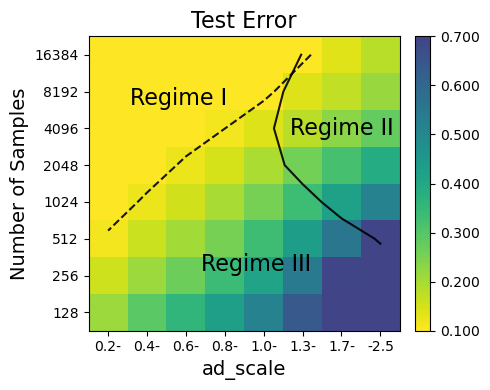

In [172]:
import numpy as np
import matplotlib.pyplot as plt

pde_settings = ad_scale_labels
lr = lr_range[0]
## 8x8 array
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

for scale_key in ad_scale_keys:
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), ad_scale_keys.index(scale_key)] = exp_stats[scale_key][hyper_setting]['test_err_mean']

test_loss_grid = loss.copy()

train_loss_for_boundary = np.zeros_like(loss)
for scale_key in ad_scale_keys:
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        train_loss_for_boundary[sub_sampling_range.index(subsamples), ad_scale_keys.index(scale_key)] = exp_stats[scale_key][hyper_setting]['train_err_mean']


fig, ax = plt.subplots(1, 1, figsize=(5, 4))

X, Y = np.meshgrid(np.arange(len(pde_settings)), np.arange(len(sub_sampling_range)))
soft_seismic = truncated_cmap("viridis_r", minval=0.0, maxval=0.8)
heatmap = ax.pcolormesh(X, Y, loss, cmap=soft_seismic, shading='auto', rasterized=True, vmin=0.1, vmax=0.7)

ax.set_xticks(np.arange(len(pde_settings)))
ax.set_xticklabels(pde_settings, fontsize=ticks_fontsize)
ax.set_yticks(np.arange(len(sub_sampling_range)))
ax.set_yticklabels(data_number_range, fontsize=ticks_fontsize)

ax.set_xlabel("ad_scale", fontsize=label_fontsize)
ax.set_ylabel("Number of Samples", fontsize=label_fontsize)
ax.set_title("Test Error", fontsize=16)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=ticks_fontsize)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_colorbar_tick))

# regime_lines = build_regime_lines(loss.shape)
# for xs, ys in regime_lines:
#     ax.plot(xs, ys, **REGIME_LINE_STYLE)

ax.text(x=1.8, y=5.8, s="Regime I", ha='center', va='center', fontsize=16, fontweight="normal", color="black")
ax.text(x=3.8, y=1.3, s="Regime III", ha='center', va='center', fontsize=16, fontweight="normal", color="black")
ax.text(x=6.0, y=5.0, s="Regime II", ha='center', va='center', fontsize=16, fontweight="normal", color="black")



draw_boundary(ax, loss, line_style=BOUNDARY_LINE_STYLE_TEST)
try:
    draw_boundary(ax, train_loss_for_boundary, line_style=BOUNDARY_LINE_STYLE_TRAIN)
except NameError:
    pass

try:
    draw_fused_boundary(ax, train_loss_for_boundary, loss)
except NameError:
    pass
plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/pdf/test_error_ad_scale.pdf', bbox_inches='tight')
plt.show()


### 8 × 8 grid - Training Error

(8, 8)


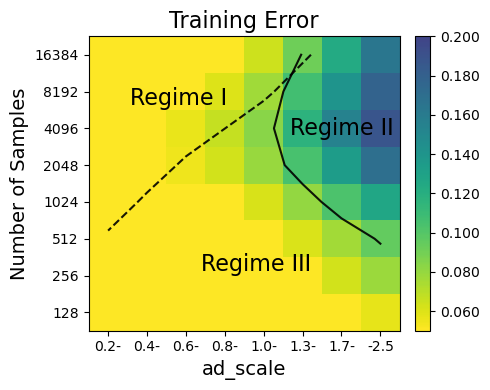

In [173]:
import numpy as np
import matplotlib.pyplot as plt

pde_settings = ad_scale_labels
lr = lr_range[0]
## 8x8 array
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

for scale_key in ad_scale_keys:
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), ad_scale_keys.index(scale_key)] = exp_stats[scale_key][hyper_setting]['train_err_mean']

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

X, Y = np.meshgrid(np.arange(len(pde_settings)), np.arange(len(sub_sampling_range)))
soft_seismic = truncated_cmap("viridis_r", minval=0.0, maxval=0.8)
heatmap = ax.pcolormesh(X, Y, loss, cmap=soft_seismic, shading='auto', rasterized=True, vmin=0.05, vmax=0.2)

ax.set_xticks(np.arange(len(pde_settings)))
ax.set_xticklabels(pde_settings, fontsize=ticks_fontsize)
ax.set_yticks(np.arange(len(sub_sampling_range)))
ax.set_yticklabels(data_number_range, fontsize=ticks_fontsize)

ax.set_xlabel("ad_scale", fontsize=label_fontsize)
ax.set_ylabel("Number of Samples", fontsize=label_fontsize)
ax.set_title("Training Error", fontsize=16)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=ticks_fontsize)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_colorbar_tick))

# regime_lines = build_regime_lines(loss.shape)
# for xs, ys in regime_lines:
#     ax.plot(xs, ys, **REGIME_LINE_STYLE)

ax.text(x=1.8, y=5.8, s="Regime I", ha='center', va='center', fontsize=16, fontweight="normal", color="black")
ax.text(x=3.8, y=1.3, s="Regime III", ha='center', va='center', fontsize=16, fontweight="normal", color="black")
ax.text(x=6.0, y=5.0, s="Regime II", ha='center', va='center', fontsize=16, fontweight="normal", color="black")


draw_boundary(ax, loss, line_style=BOUNDARY_LINE_STYLE_TRAIN)
try:
    draw_boundary(ax, test_loss_grid, line_style=BOUNDARY_LINE_STYLE_TEST)
except NameError:
    pass

try:
    draw_fused_boundary(ax, loss, test_loss_grid)
except NameError:
    pass
plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/pdf/train_error_ad_scale.pdf', bbox_inches='tight')
plt.show()
